In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import IsolationForest
from scipy.linalg import lstsq
from sklearn.model_selection import train_test_split
import cvxpy as cp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


In [2]:
df_data = pd.read_parquet("../training_data/initial_dataset.parquet")
df_train_detached = pd.read_parquet(
    "../training_data/data_detached_with_weather.parquet")
type(df_data)
type(df_train_detached)
df_train_detached

unique_ids = df_train_detached["Property_ID"].unique()
id_use = unique_ids[0]
df_house = pd.read_csv('../training_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual","HP_Size_kW"
]

# calculate min capacity in home 
cp_air = 1.005  #kJ/kgK
rho_air = 1.225  # kg/m^3
kj_to_kWh = 1/3600
df_house["Volume"] = df_house["Total_Floor_Area"] * df_house["Floor_Height"]
df_house["Min Capacity"] = df_house["Volume"] * cp_air * rho_air * kj_to_kWh

df_home_values = df_house[df_house["Property_ID"].isin(unique_ids)]

summary = df_home_values[["Property_ID", "Min Capacity"]].drop_duplicates()
print(summary)

home_dict = df_home_values.set_index("Property_ID").to_dict(orient="index")

     Property_ID  Min Capacity
76       EOH3196      0.086941
318      EOH0413      0.094570
585      EOH2329      0.099645
736      EOH1637      0.088733
1149     EOH3154      0.116411
1156     EOH2675      0.124696
1569     EOH1485      0.115696
1692     EOH0546      0.088239
2066     EOH0279      0.138493
2381     EOH1703      0.074688


In [3]:
df_single = df_train_detached[
df_train_detached["Property_ID"] == id_use].copy()

#re-adjust Heat Pump Diff and add temp differences
df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
    "Heat_Pump_Energy_Output"].diff()
df_single["Internal_Temperature_Diff"] = df_single[
    "Internal_Air_Temperature"].diff()
df_single["Internal_Ambient_Temperature_Diff"] = \
    (df_single["External_Air_Temperature"] -
     df_single["Internal_Air_Temperature"])

# 1. Drop columns with almost all missing data (e.g., more than 90% missing)
threshold = 0.90 * len(df_single)
df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
#print("Columns dropped due to high missing values:")
#print(df_single.columns.difference(df_single_cleaned.columns).tolist())

df_single = df_single_cleaned

#print("\nColumns remaining after dropping highly missing columns:")
#print(df_single.columns.tolist())

df_single = df_single.set_index('Timestamp')
df_single = df_single.sort_index()

# Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
numeric_cols = df_single.select_dtypes(include=['number']).columns
df_single_numeric_interpolated = df_single[numeric_cols].interpolate(
    method='time', limit=4, limit_direction='both')

df_single_interpolated = df_single.copy()
df_single_interpolated[numeric_cols] = df_single_numeric_interpolated

# After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
initial_rows = len(df_single_interpolated)
df_single_processed = df_single_interpolated.dropna()

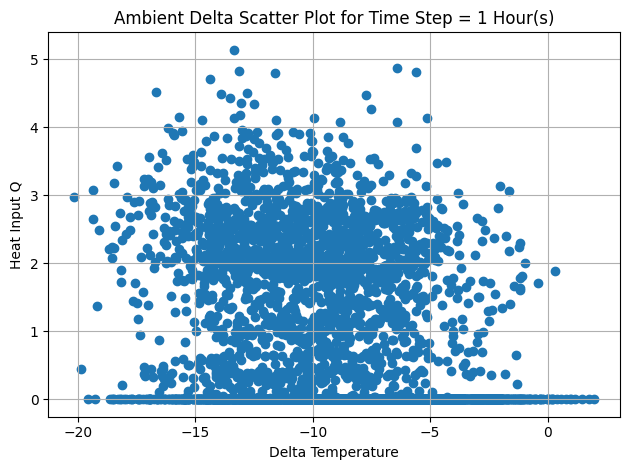

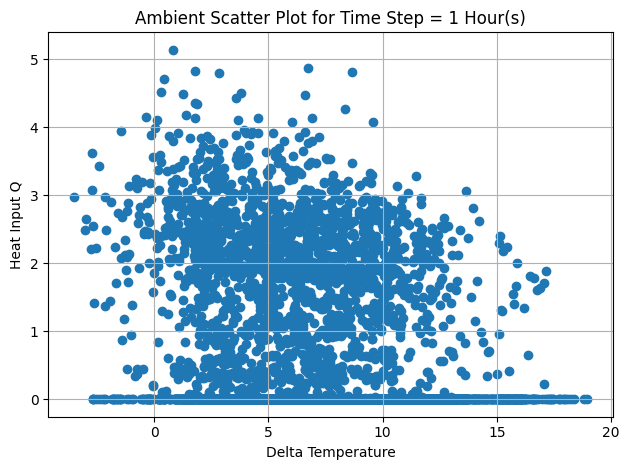

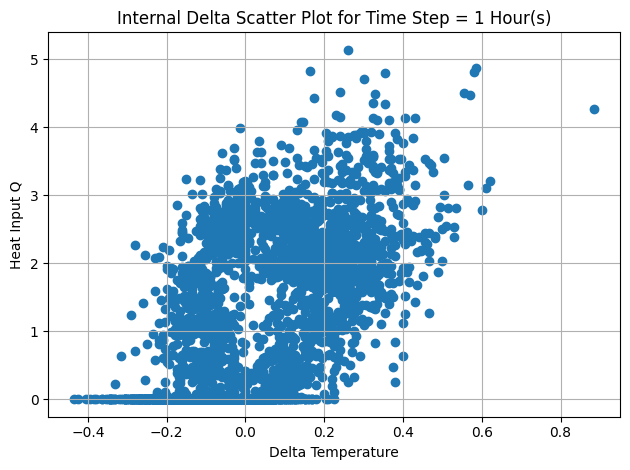

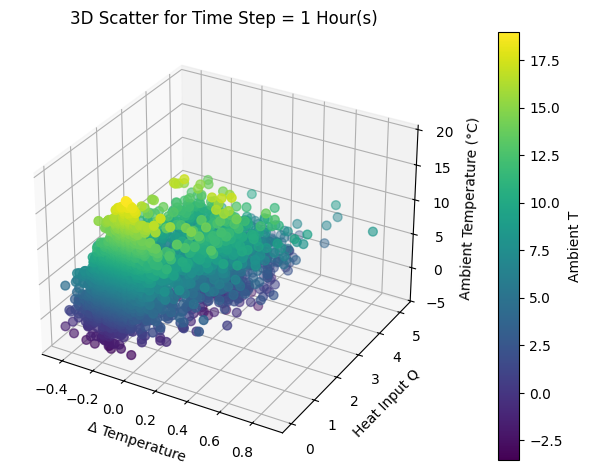

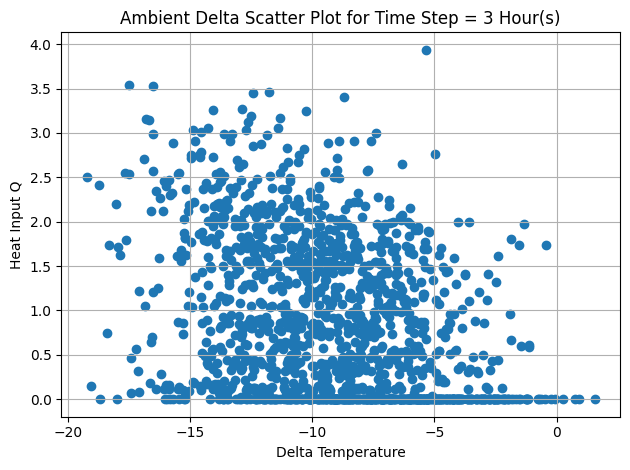

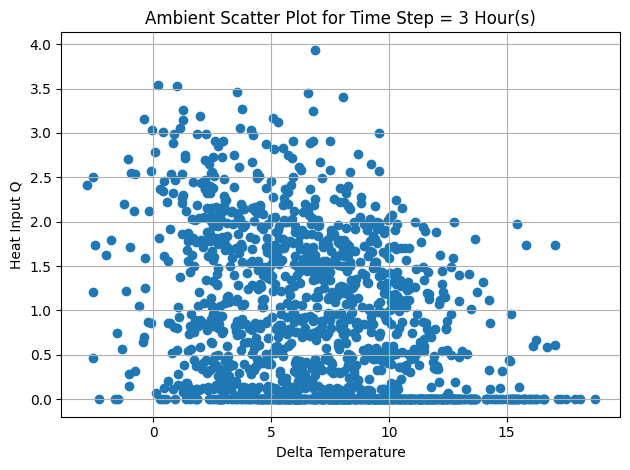

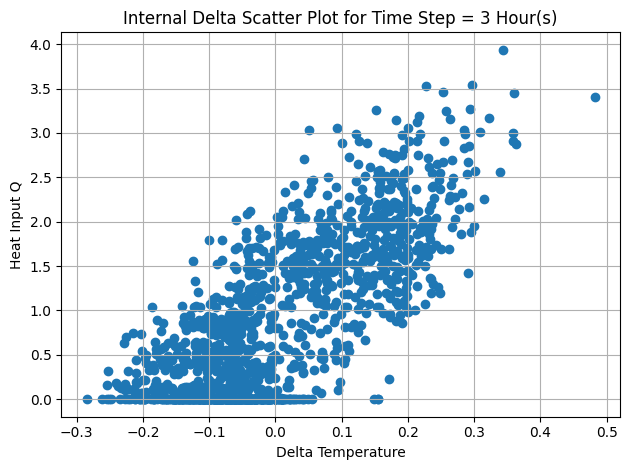

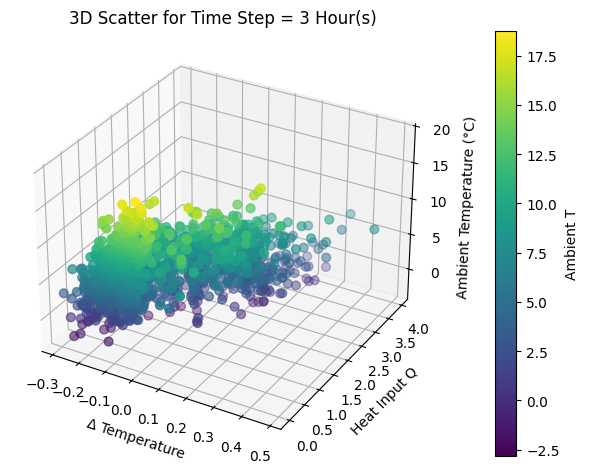

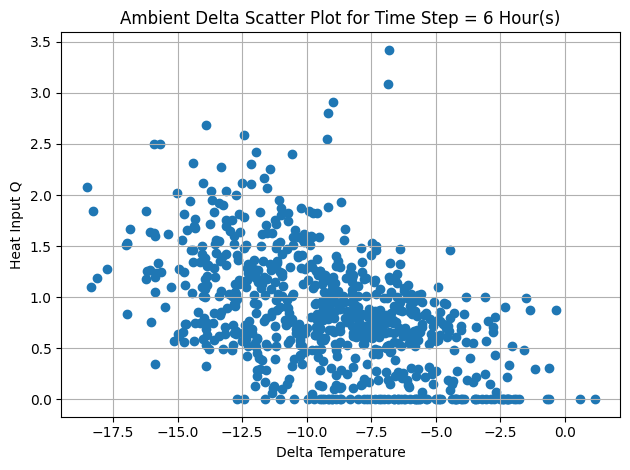

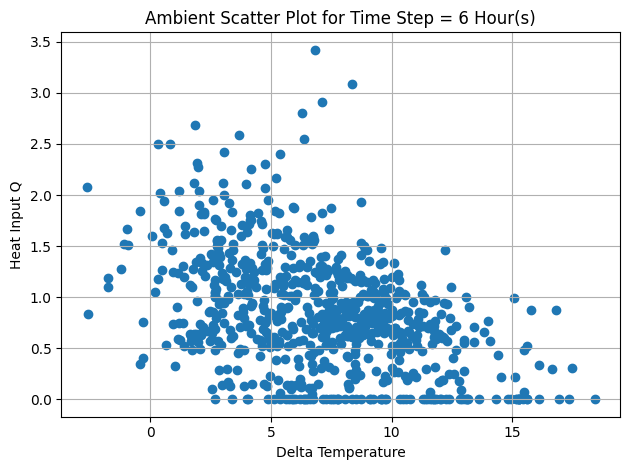

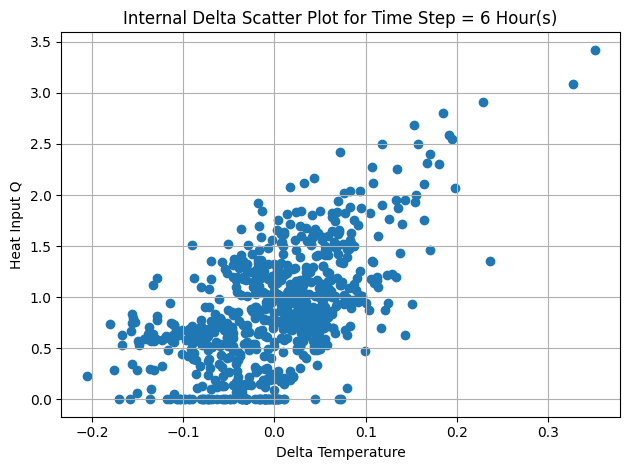

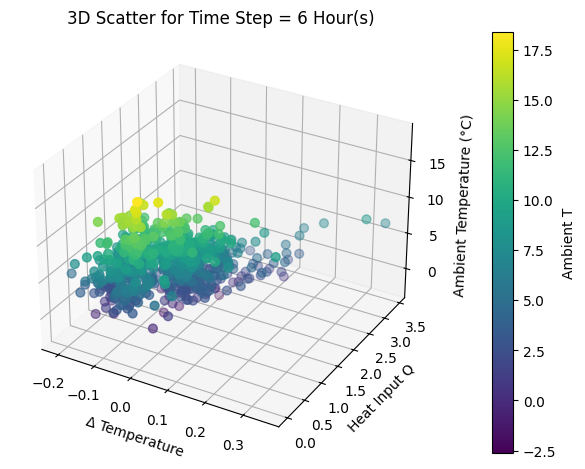

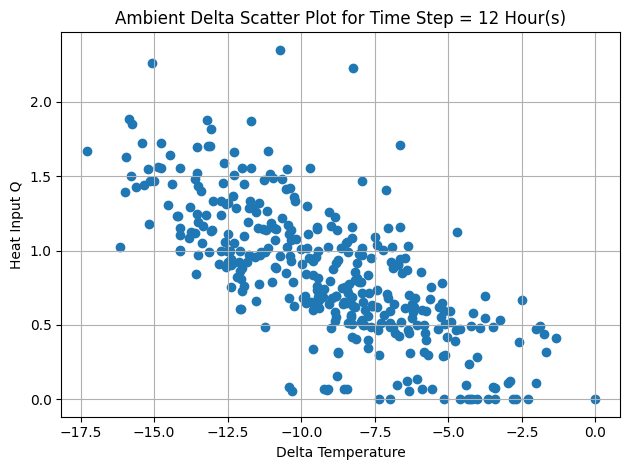

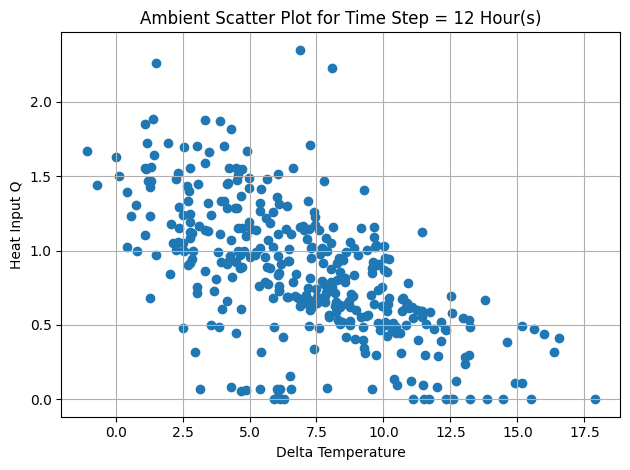

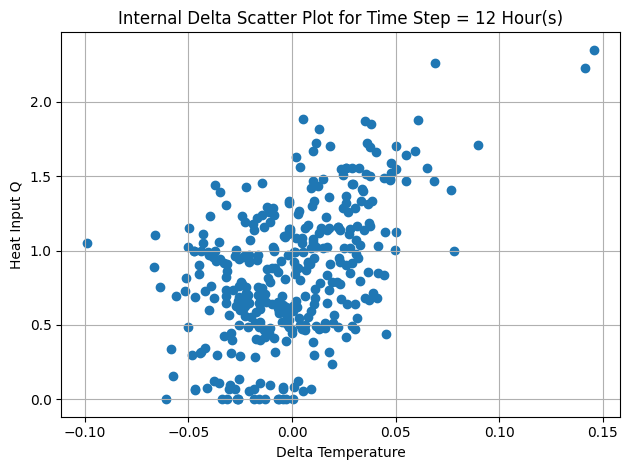

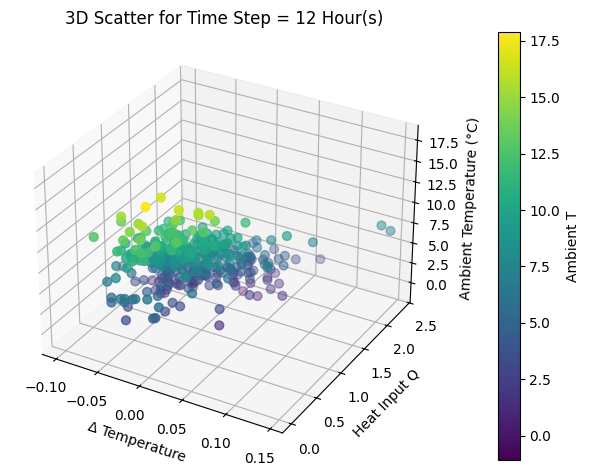

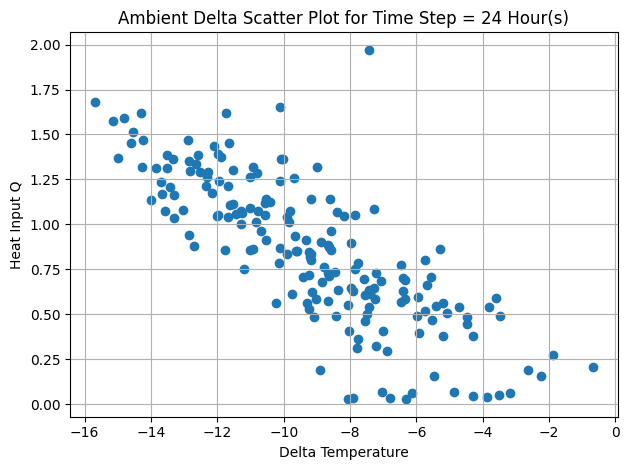

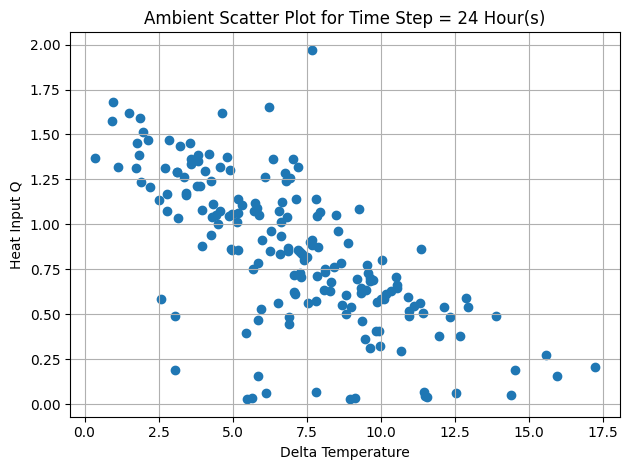

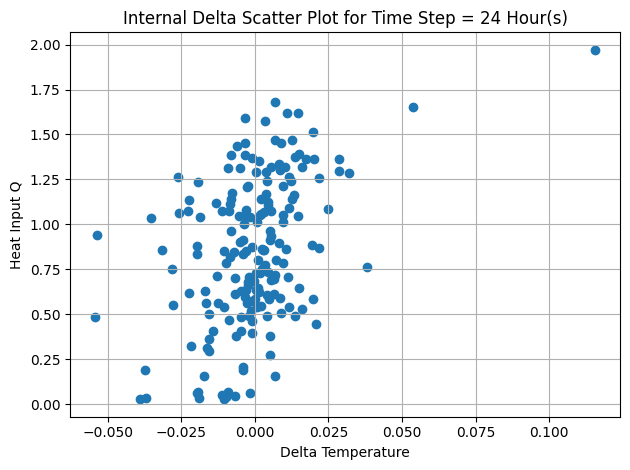

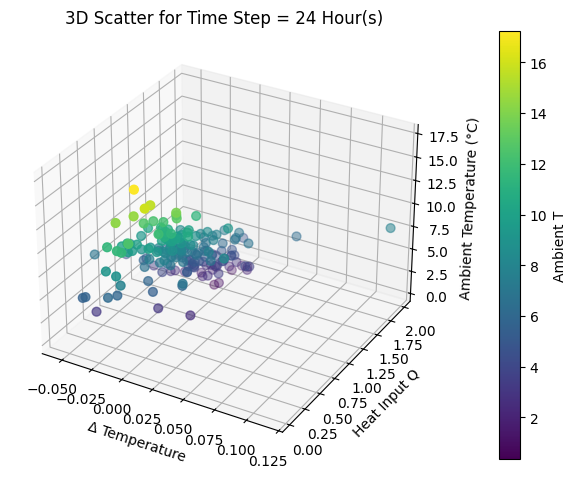

In [4]:
df_heating_single = df_single_processed.copy()

# Time range
t_start = pd.to_datetime("2021-10-01 00:00:00")
t_end = pd.to_datetime("2022-3-31 23:59:00")
df_heating_only = df_heating_single[
    (df_heating_single.index >= t_start) & (df_heating_single.index <= t_end)
].copy()

df_heating_only.drop("Property_ID", axis=1, inplace=True)
df_heating_only.drop("half-hour", axis=1, inplace=True)
df_heating_only.drop("Date", axis=1, inplace=True)
df_heating_only.drop("has_data", axis=1, inplace=True)


t_step_try = [1, 3, 6, 12, 24]

for i in t_step_try:
    df_numeric = df_heating_only.select_dtypes(include='number')

    # Resample and compute mean
    df_resampled = df_numeric.resample(f'{i}h').mean()

    # Extract variables
    delta_T_a_heat = df_resampled["Internal_Ambient_Temperature_Diff"]
    q_heat_only = df_resampled["Heat_Pump_Energy_Output_Diff"]
    delta_T_i_heat = df_resampled["Internal_Temperature_Diff"]
    T_ambient = df_resampled["External_Air_Temperature"]
    # Create new scatter plot
    plt.figure()
    plt.scatter(delta_T_a_heat, q_heat_only)
    plt.title(f"Ambient Delta Scatter Plot for Time Step = {i} Hour(s)")
    plt.xlabel("Delta Temperature")
    plt.ylabel("Heat Input Q")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    plt.figure()
    plt.scatter(T_ambient, q_heat_only)
    plt.title(f"Ambient Scatter Plot for Time Step = {i} Hour(s)")
    plt.xlabel("Delta Temperature")
    plt.ylabel("Heat Input Q")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    plt.figure()
    plt.scatter(delta_T_i_heat, q_heat_only)
    plt.title(f"Internal Delta Scatter Plot for Time Step = {i} Hour(s)")
    plt.xlabel("Delta Temperature")
    plt.ylabel("Heat Input Q")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    fig = plt.figure()
    ax  = fig.add_subplot(111, projection='3d')
    p   = ax.scatter(
        delta_T_i_heat,
        q_heat_only,
        T_ambient,           # third axis
        c=T_ambient,
        cmap='viridis',
        depthshade=True,
        s=40
    )
    ax.set_xlabel("Δ Temperature")
    ax.set_ylabel("Heat Input Q")
    ax.set_zlabel("Ambient Temperature (°C)")
    fig.colorbar(p, ax=ax, pad=0.1, label='Ambient T')
    plt.title(f"3D Scatter for Time Step = {i} Hour(s)")
    plt.tight_layout()
    plt.show()
    


Total windows:    2184
Anomalies found:  437


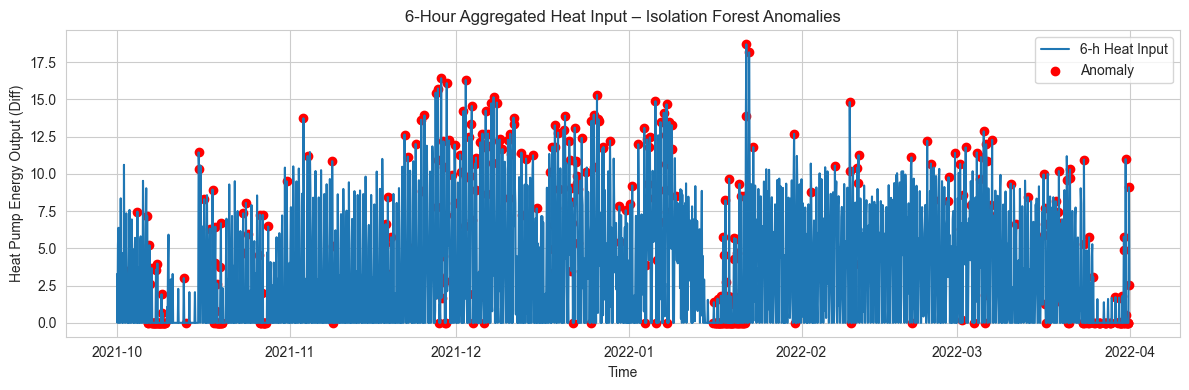

In [25]:
# 1. Subset to your desired time range
t_start = pd.to_datetime("2021-10-01 00:00:00")
t_end   = pd.to_datetime("2022-03-31 23:59:00")
df = df_heating_single.loc[t_start:t_end].copy()

# 2. Add the sinusoidal time‐of‐day features
df['sin_h'] = np.sin(2 * np.pi * df.index.hour / 24)
df['cos_h'] = np.cos(2 * np.pi * df.index.hour / 24)

# 3. Resample to 6-hour windows
agg_dict = {
    'Heat_Pump_Energy_Output_Diff': 'sum',   # total heat input
    'Internal_Ambient_Temperature_Diff': 'mean',
    'External_Air_Temperature': 'mean',
    'Internal_Temperature_Diff': 'mean',
    'Internal_Air_Temperature': 'mean',
    'sin_h': 'mean',
    'cos_h': 'mean'
}
df6h = df.resample('2h').agg(agg_dict).dropna()

# 4. Prepare your feature matrix
features = [
    'Heat_Pump_Energy_Output_Diff',
    'Internal_Ambient_Temperature_Diff',
    'External_Air_Temperature',
    'Internal_Temperature_Diff',
    'Internal_Air_Temperature',
    'sin_h',
    'cos_h'
]
X = df6h[features]

# 5. Fit the Isolation Forest (no `behaviour` parameter)
iso = IsolationForest(
    n_estimators=100,
    contamination=0.20,    # expecting ~x% anomalies
    random_state=42
)
iso.fit(X)

# 6. Score and flag anomalies
df6h['anomaly_score'] = iso.decision_function(X)   # higher → more normal
df6h['is_anomaly']    = iso.predict(X) == -1       # -1 = anomaly

# 7. Quick summary
print(f"Total windows:    {len(df6h)}")
print(f"Anomalies found:  {df6h['is_anomaly'].sum()}")

# 8. Plot the 6-h heat input with anomalies highlighted
plt.figure(figsize=(12, 4))
plt.plot(df6h.index, df6h['Heat_Pump_Energy_Output_Diff'], label='6-h Heat Input')
plt.scatter(
    df6h.index[df6h['is_anomaly']],
    df6h.loc[df6h['is_anomaly'], 'Heat_Pump_Energy_Output_Diff'],
    color='red',
    label='Anomaly'
)
plt.title("6-Hour Aggregated Heat Input – Isolation Forest Anomalies")
plt.xlabel("Time")
plt.ylabel("Heat Pump Energy Output (Diff)")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# ──────────────────────────────────────────────────────────────────────────────
# 9. Identify which calendar days have ≥1 anomaly
df6h['date'] = df6h.index.date
anomaly_days = np.unique(df6h.loc[df6h['is_anomaly'], 'date'])
print(f"\nNumber of days with at least one anomaly: {len(anomaly_days)}")

# 10. Compute daily metrics (from the 6-h windows)
daily_metrics = (
    df6h
    .groupby('date')
    .agg(daily_heat_input       = ('Heat_Pump_Energy_Output_Diff', 'sum'),
         mean_external_temp     = ('External_Air_Temperature',       'mean'),
         mean_internal_temp     = ('Internal_Air_Temperature',       'mean'))
)

# 11. Filter to only those anomaly days
daily_anomaly = daily_metrics.loc[anomaly_days]

# 12. Show a few example days
print("\nExample anomaly days and their daily metrics:")
print(daily_anomaly.sample(5))    # pick 5 random example dayse


Number of days with at least one anomaly: 113

Example anomaly days and their daily metrics:
            daily_heat_input  mean_external_temp  mean_internal_temp
date                                                                
2022-03-21            42.363            3.955000           16.649375
2022-01-30            66.098            4.810417           16.703750
2022-01-05            76.280            1.881354           16.688958
2022-02-28            39.347            7.500417           16.714583
2021-11-29            69.730            3.551875           15.192500


In [22]:
anomaly_days[3]

datetime.date(2021, 10, 9)

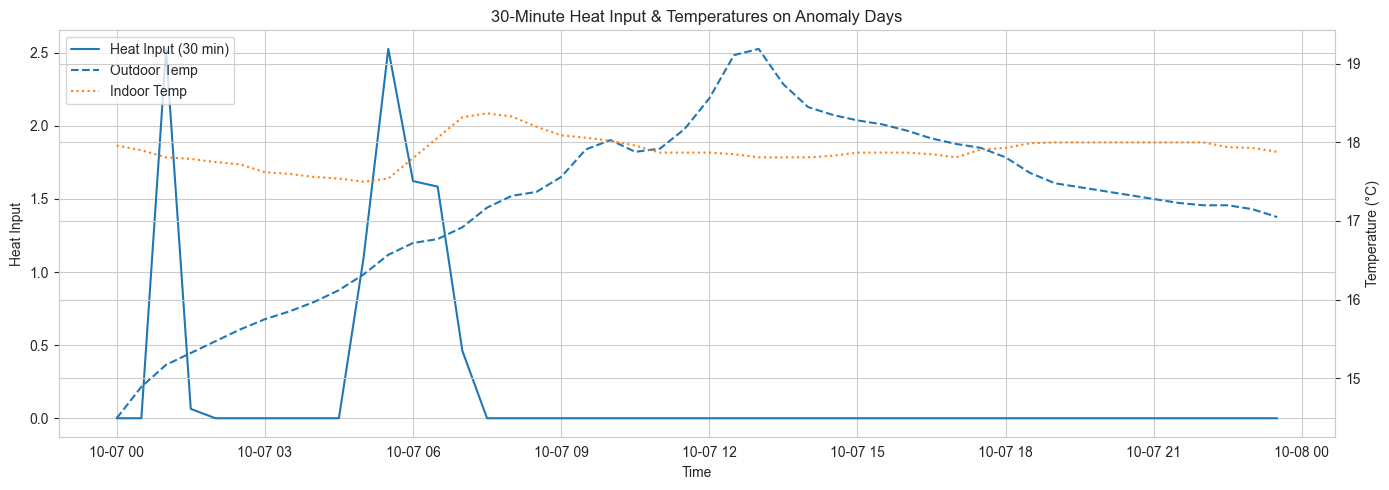

In [28]:

# 1. Re-filter your original 30-min data to the same date range
df30 = df_heating_single.loc[t_start:t_end].copy()

# 2. Keep only the anomaly days via np.isin
mask = np.isin(df30.index.date, anomaly_days[3])
df30 = df30[mask]

# 3. Plot everything
fig, ax1 = plt.subplots(figsize=(14, 5))

# Heat input on primary y-axis
l1, = ax1.plot(
    df30.index,
    df30['Heat_Pump_Energy_Output_Diff'],
    label='Heat Input (30 min)',
)
ax1.set_xlabel('Time')
ax1.set_ylabel('Heat Input')
ax1.tick_params(axis='y')

# Temperature on a secondary y-axis
ax2 = ax1.twinx()
l2, = ax2.plot(
    df30.index,
    df30['External_Air_Temperature'],
    linestyle='--',
    label='Outdoor Temp'
)
l3, = ax2.plot(
    df30.index,
    df30['Internal_Air_Temperature'],
    linestyle=':',
    label='Indoor Temp'
)
ax2.set_ylabel('Temperature (°C)')
ax2.tick_params(axis='y')

# Combine legends
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('30-Minute Heat Input & Temperatures on Anomaly Days')
plt.tight_layout()
plt.show()


In [37]:

from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler

# ────────────────────────────────────────────────────────────────────────────────
# 1) Load + Resample (e.g. 3-hour steps)
df = df_heating_single.loc["2021-10-01":"2022-03-31"].copy()
df['sin_h'] = np.sin(2*np.pi*df.index.hour/24)
df['cos_h'] = np.cos(2*np.pi*df.index.hour/24)

df_res = df.resample('3H').agg({
    'Heat_Pump_Energy_Output_Diff':'sum',
    'External_Air_Temperature':'mean',
    'Internal_Air_Temperature':'mean',
    'sin_h':'mean','cos_h':'mean'
}).dropna()

# 2) Create TimeSeries
ts_heat = TimeSeries.from_dataframe(df_res, value_cols='Heat_Pump_Energy_Output_Diff')
ts_exog = TimeSeries.from_dataframe(df_res, value_cols=[
    'External_Air_Temperature','Internal_Air_Temperature','sin_h','cos_h'
])

# 3) Train/val split & scaling
train_heat, val_heat = ts_heat.split_before(0.8)
train_exog,  val_exog  = ts_exog.split_before(0.8)

scaler_y   = Scaler(); scaler_exo = Scaler()
train_heat = scaler_y.fit_transform(train_heat)
val_heat   = scaler_y.transform(val_heat)
train_exog = scaler_exo.fit_transform(train_exog)
val_exog   = scaler_exo.transform(val_exog)

# 4) Instantiate & fit N-BEATS (with MC dropout)
history_hours       = 24
freq_hours          = 3
input_chunk_length  = history_hours // freq_hours
output_chunk_length = 1

model = NBEATSModel(
    input_chunk_length  = input_chunk_length,
    output_chunk_length = output_chunk_length,
    dropout             = 0.1,      # MC Dropout
    n_epochs            = 100,
    random_state        = 42,
    pl_trainer_kwargs   = {"accelerator":"cpu"}
)

model.fit(
    series               = train_heat,
    past_covariates      = train_exog,
    val_series           = val_heat,
    val_past_covariates  = val_exog,
    verbose              = True
)

# ────────────────────────────────────────────────────────────────────────────────
# 5) —— NEW BLOCK: Rolling 1-step Quantile Forecasts via MC Dropout —— #




/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_47513/2339842429.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_res = df.resample('3H').agg({
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.3 M  | tra

/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 0: 100%|██████████| 37/37 [00:02<00:00, 18.50it/s, train_loss=0.0205]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 37/37 [00:01<00:00, 18.92it/s, train_loss=0.00974, val_loss=0.0556]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 37/37 [00:02<00:00, 18.01it/s, train_loss=0.00248, val_loss=0.0324]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 37/37 [00:02<00:00, 17.84it/s, train_loss=0.0165, val_loss=0.0252] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 37/37 [00:02<00:00, 17.45it/s, train_loss=0.0395, val_loss=0.0301]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 37/37 [00:02<00:00, 17.68it/s, train_loss=0.0356, val_loss=0.028] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 37/37 [00:02<00:00, 17.14it/s, train_loss=0.0632, val_loss=0.0289] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██████████| 37/37 [00:02<0

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 37/37 [00:02<00:00, 15.71it/s, train_loss=0.00217, val_loss=0.0269]


TypeError: historical_forecasts() got an unexpected keyword argument 'mc_dropout'

In [39]:
# … after model.fit(…) …

# 1) determine your “backtest” start index (e.g. 80% in)
start_frac = 0.8
start_idx  = int(len(ts_heat) * start_frac)

# prepare lists for your bands
timestamps  = ts_heat.time_index[start_idx:]
lower_vals  = []
median_vals = []
upper_vals  = []

# 2) roll through each step and sample via MC dropout
for t in range(start_idx, len(ts_heat)):
    hist_series  = ts_heat[:t]
    hist_cov     = ts_exog[:t]

    # one‐step MC‐dropout forecast
    pf = model.predict(
        n               = 1,
        series          = hist_series,
        past_covariates = hist_cov,
        mc_dropout      = True,
        num_samples     = 200
    )

    # ← replace quantile_timeseries() with quantile(q)
    lower_vals.append( pf.quantile(0.05).values()[0][0] )
    median_vals.append(pf.quantile(0.50).values()[0][0])
    upper_vals.append( pf.quantile(0.95).values()[0][0] )

# 3) build time series for your bands
lower  = TimeSeries.from_times_and_values(timestamps, np.array(lower_vals))
median = TimeSeries.from_times_and_values(timestamps, np.array(median_vals))
upper  = TimeSeries.from_times_and_values(timestamps, np.array(upper_vals))

# 4) align the observed slice
obs = ts_heat[start_idx:]

# 5) anomaly mask = outside [lower, upper]
mask = (obs < lower) | (obs > upper)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/levipremer/PycharmProjects/uk_data_electric_heating/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 12.94it/s]

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 21.58it/s]

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 15.84it/s]


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 17.81it/s]


KeyError: 'Not all components found in time index.'


KeyError: 'Not all components found in time index.'

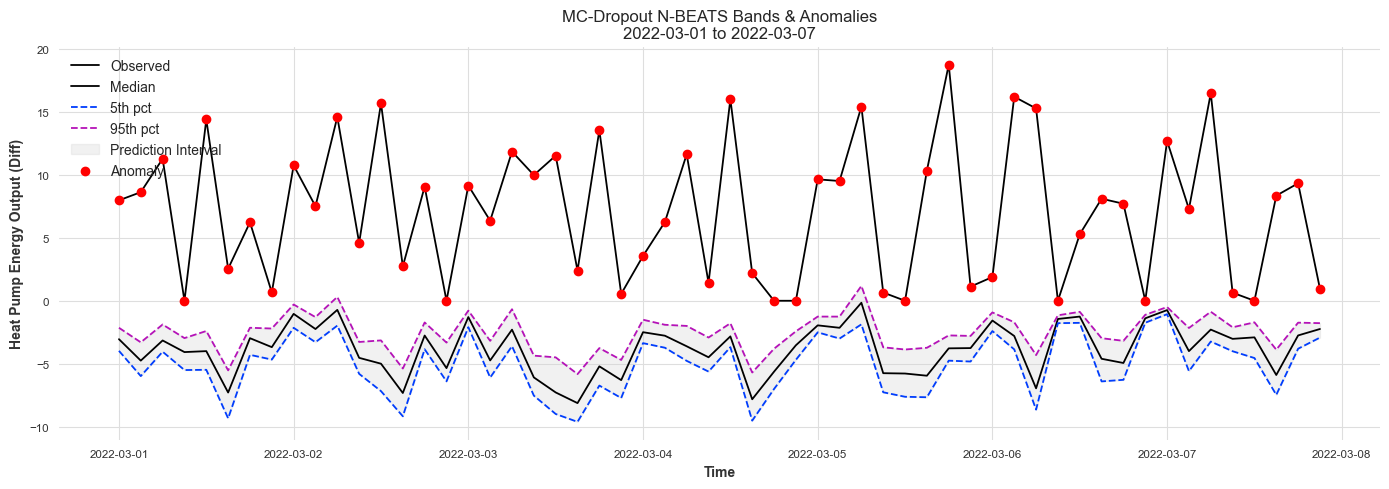

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Define your window
start_ts = pd.Timestamp("2022-03-01 00:00:00")
end_ts   = pd.Timestamp("2022-03-07 23:59:59")

# 2) Slice each Darts TimeSeries
obs_ts   = obs.slice(start_ts, end_ts)
low_ts   = lower.slice(start_ts, end_ts)
med_ts   = median.slice(start_ts, end_ts)
upp_ts   = upper.slice(start_ts, end_ts)

# 3) Convert them to pandas.Series
obs_pd = pd.Series(obs_ts.values().flatten(),  index=obs_ts.time_index, name="obs")
med_pd = pd.Series(med_ts.values().flatten(),  index=med_ts.time_index, name="med")
low_pd = pd.Series(low_ts.values().flatten(),  index=low_ts.time_index, name="low")
upp_pd = pd.Series(upp_ts.values().flatten(),  index=upp_ts.time_index, name="upp")

# 4) Rebuild the anomaly mask in pandas
mask_pd = (obs_pd < low_pd) | (obs_pd > upp_pd)

# 5) Extract anomaly points
anom_idx  = mask_pd[mask_pd].index
anom_vals = obs_pd.loc[anom_idx]

# 6) Plot
plt.figure(figsize=(14,5))

plt.plot(obs_pd.index, obs_pd,      label="Observed")
plt.plot(med_pd.index, med_pd,      color="black", label="Median")
plt.plot(low_pd.index, low_pd,      "--",          label="5th pct")
plt.plot(upp_pd.index, upp_pd,      "--",          label="95th pct")
plt.fill_between(
    low_pd.index,
    low_pd.values,
    upp_pd.values,
    color="lightgray", alpha=0.3,
    label="Prediction Interval"
)

plt.scatter(
    anom_idx,
    anom_vals,
    color="red",
    label="Anomaly",
    zorder=5
)

plt.title(f"MC-Dropout N-BEATS Bands & Anomalies\n{start_ts.date()} to {end_ts.date()}")
plt.xlabel("Time")
plt.ylabel("Heat Pump Energy Output (Diff)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Define your window endpoints
start_ts = pd.Timestamp("2022-03-01 00:00:00")
end_ts   = pd.Timestamp("2022-03-07 23:59:59")

# 2) Slice each Darts TimeSeries
obs_ts =    obs.slice(start_ts, end_ts)
low_ts =    lower.slice(start_ts, end_ts)
med_ts =    median.slice(start_ts, end_ts)
upp_ts =    upper.slice(start_ts, end_ts)
mask_ts =   mask.slice(start_ts, end_ts)

# 3) Build pandas Series directly
obs_pd  = pd.Series(obs_ts.values().flatten(),  index=obs_ts.time_index, name="obs")
med_pd  = pd.Series(med_ts.values().flatten(),  index=med_ts.time_index, name="median")
low_pd  = pd.Series(low_ts.values().flatten(),  index=low_ts.time_index, name="low")
upp_pd  = pd.Series(upp_ts.values().flatten(),  index=upp_ts.time_index, name="upp")
mask_pd = pd.Series(mask_ts.values().flatten(), index=mask_ts.time_index, name="mask").astype(bool)

# 4) Extract anomaly points
anom_idx  = mask_pd[mask_pd].index
anom_vals = obs_pd.loc[anom_idx]

# 5) Plot
plt.figure(figsize=(14,5))

plt.plot(obs_pd.index, obs_pd.values, label="Observed")
plt.plot(med_pd.index, med_pd.values, color="black", label="Median")
plt.plot(low_pd.index, low_pd.values,  "--",    label="5th pct")
plt.plot(upp_pd.index, upp_pd.values,  "--",    label="95th pct")
plt.fill_between(
    low_pd.index,
    low_pd.values,
    upp_pd.values,
    color="lightgray", alpha=0.3,
    label="Prediction Interval"
)
plt.scatter(
    anom_idx,
    anom_vals,
    color="red",
    label="Anomaly",
    zorder=5
)

plt.title(f"MC-Dropout N-BEATS Bands & Anomalies\n{start_ts.date()} to {end_ts.date()}")
plt.xlabel("Time")
plt.ylabel("Heat Pump Energy Output (Diff)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'slice'